# Queue races, direction and waiting time

The ask/bid race begins at (2,1). Compare the exact regenerative variance rate with independently generated cycles. Positive within-cycle covariance has an effect whose sign depends on drift.

Synthetic data only. All settings and random seeds are specified below.

In [1]:
from pathlib import Path
import sys, json, platform
import numpy as np
import pandas as pd
# Embed figures in saved notebook outputs, even when MPLBACKEND=Agg.
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "src"))
OUT = ROOT / "results" / "synthetic" / "queues"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": .2})
print({"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__})


{'python': '3.12.0', 'numpy': '1.26.0', 'pandas': '2.1.1'}


,p,p_up,empirical_p_up,theory_rate,independent_rate,estimated_rate,cov_jt,drift
0,0.500000,0.2500,0.24725,1.481481,1.259259,1.481606,0.125000,-6.666667e-01
1,0.707107,0.5000,0.50271,1.171573,1.171573,1.171040,0.146447,-2.276238e-16
2,0.850000,0.7225,0.72331,0.877966,0.990695,0.873825,0.108375,4.810811e-01


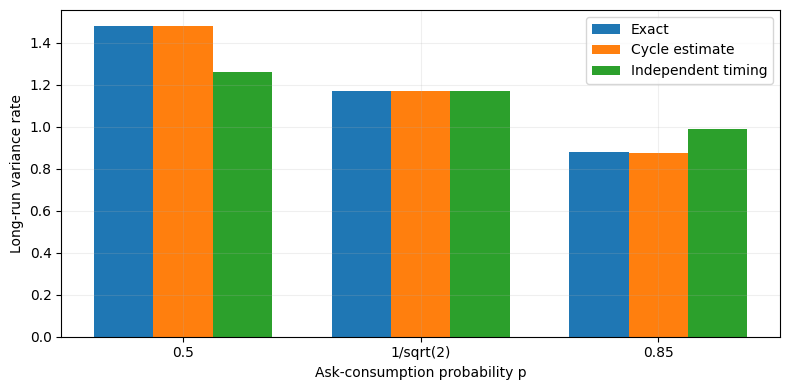

In [2]:
from queue_models.queue_race import theory,sample_cycles,cycle_estimate
rows=[]
for i,p in enumerate((.5,1/np.sqrt(2),.85)):
    config=dict(ask=2,bid=1,p=p,rate=2.,delta=1.)
    jumps,times,_=sample_cycles(np.random.default_rng(610+i),100000,**config)
    exact=theory(**config);estimate=cycle_estimate(jumps,times)
    rows.append(dict(p=p,p_up=exact["p_up"],empirical_p_up=float((jumps>0).mean()),theory_rate=exact["variance_rate"],independent_rate=exact["independent_rate"],estimated_rate=estimate["variance_rate"],cov_jt=exact["cov_jt"],drift=exact["drift"]))
table=pd.DataFrame(rows);display(table)
table.to_csv(OUT/"queue_race.csv",index=False)
x=np.arange(len(table));width=.25
for offset,col,label in [(-1,"theory_rate","Exact"),(0,"estimated_rate","Cycle estimate"),(1,"independent_rate","Independent timing")]:
    plt.bar(x+offset*width,table[col],width,label=label)
plt.xticks(x,["0.5","1/sqrt(2)","0.85"]);plt.xlabel("Ask-consumption probability p");plt.ylabel("Long-run variance rate");plt.legend()
plt.tight_layout();plt.savefig(OUT/"queue_race.png",dpi=140);plt.show()


## Interpretation

Compare the displayed model reference with the simulation. Finite-sample agreement is an implementation check, not evidence of real-market calibration. See [assumptions](../../../docs/model_assumptions.md) and [limitations](../../../docs/validation_and_limitations.md).